In [2]:
import torch
import torch.nn.functional as F
import pandas as pd 
from plotnine import *
four_labels = torch.tensor([0,2,1,1])
four_pred = torch.tensor([[0.4, 0.3, 0.3],
                         [ 0.2, 0.1, 0.7],
                         [0.5,0.2,0.3],
                         [0.3,0.4,0.3]])
def ROC_curve_micro(pred_tensor, label_tensor):
    n_class=pred_tensor.size(1)
    one_hot_labels = F.one_hot(label_tensor, num_classes=n_class) 
    is_positive = one_hot_labels
    is_negative =1-one_hot_labels
    fn_diff = -is_positive.flatten()
    fp_diff = is_negative.flatten()
    thresh_tensor = -pred_tensor.flatten()
    fn_denom = is_positive.sum()
    fp_denom = is_negative.sum()
    sorted_indices = torch.argsort(thresh_tensor)
    sorted_fp_cum = fp_diff[sorted_indices].cumsum(0) / fp_denom
    sorted_fn_cum = -fn_diff[sorted_indices].flip(0).cumsum(0).flip(0) / fn_denom

    sorted_thresh = thresh_tensor[sorted_indices]
    sorted_is_diff = sorted_thresh.diff() != 0
    sorted_fp_end = torch.cat([sorted_is_diff, torch.tensor([True])])
    sorted_fn_end = torch.cat([torch.tensor([True]), sorted_is_diff])

    uniq_thresh = sorted_thresh[sorted_fp_end]
    uniq_fp_after = sorted_fp_cum[sorted_fp_end]
    uniq_fn_before = sorted_fn_cum[sorted_fn_end]

    FPR = torch.cat([torch.tensor([0.0]), uniq_fp_after])
    FNR = torch.cat([uniq_fn_before, torch.tensor([0.0])])

    return {
        "FPR": FPR,
        "FNR": FNR,
        "TPR": 1 - FNR,
        "min(FPR,FNR)": torch.minimum(FPR, FNR),
        "min_constant": torch.cat([torch.tensor([-1]), uniq_thresh]),
        "max_constant": torch.cat([uniq_thresh, torch.tensor([0])])
    }
def ROC_AUC_micro(pred_tensor, label_tensor):
    roc = ROC_curve_micro(pred_tensor, label_tensor)
    FPR_diff = roc["FPR"][1:]-roc["FPR"][:-1]
    TPR_sum = roc["TPR"][1:]+roc["TPR"][:-1]
    return torch.sum(FPR_diff*TPR_sum/2.0)
def Proposed_AUM_micro(pred_tensor, label_tensor):
    roc = ROC_curve_micro(pred_tensor, label_tensor)
    min_FPR_FNR = roc["min(FPR,FNR)"][1:-1]
    constant_diff = roc["min_constant"][1:].diff()
    return torch.sum(min_FPR_FNR * constant_diff)
roc=ROC_curve_micro(four_pred,four_labels)
aum=Proposed_AUM_micro(four_pred,four_labels)
AUC=ROC_AUC_micro(four_pred,four_labels)
df=pd.DataFrame(roc)



In [3]:
df_long = pd.melt(df, id_vars=["min_constant","max_constant"],
                  value_vars=["FPR", "FNR","min(FPR,FNR)"],
                  var_name="Error type", value_name="y")
df_long['is_min'] = df_long['Error type'].apply(
    lambda t: 'min(FPR,FNR)' if t == 'min(FPR,FNR)' else 'other'
)
df_area=df[["min_constant","max_constant","min(FPR,FNR)"]]
x_top = []
y_top = []
x_bottom = []
y_bottom = []

for _, row in df_area.iterrows():
    x_top.extend([row['min_constant'], row['max_constant']])
    y_top.extend([row['min(FPR,FNR)'], row['min(FPR,FNR)']])
    
    x_bottom.extend([row['max_constant'], row['min_constant']])
    y_bottom.extend([0, 0])

poly_df = pd.DataFrame({
    'x': x_top + x_bottom,
    'y': y_top + y_bottom
})
df_long

,min_constant,max_constant,Error type,y,is_min
0,-1.0,-0.7,FPR,0.000,other
1,-0.7,-0.5,FPR,0.000,other
2,-0.5,-0.4,FPR,0.125,other
3,-0.4,-0.3,FPR,0.125,other
4,-0.3,-0.2,FPR,0.750,other
5,-0.2,-0.1,FPR,0.875,other
6,-0.1,0.0,FPR,1.000,other
7,-1.0,-0.7,FNR,1.000,other
8,-0.7,-0.5,FNR,0.750,other
9,-0.5,-0.4,FNR,0.750,other


c:\Users\nou-z\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\scales\scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


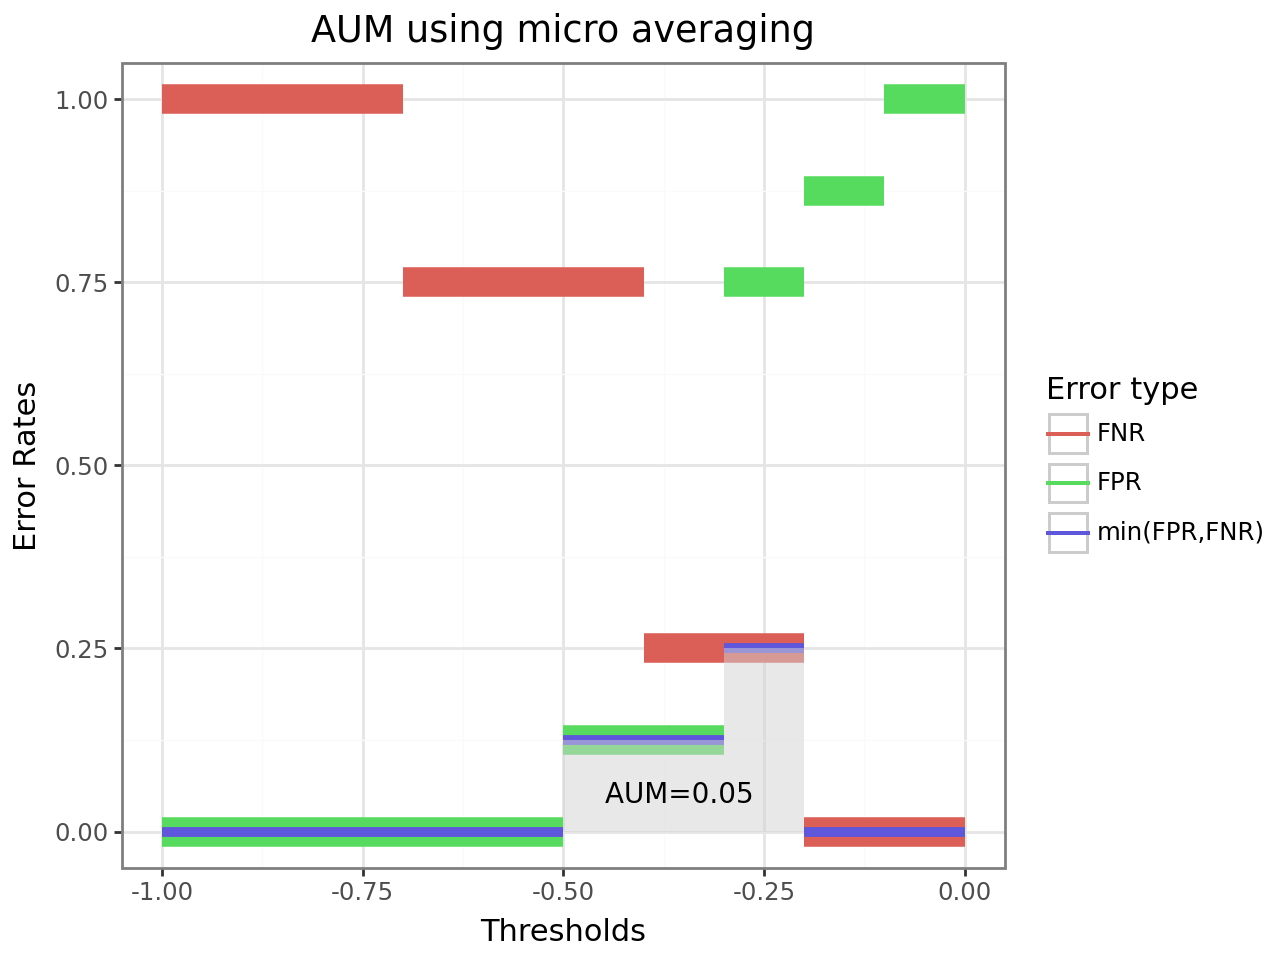

In [4]:
p = (
    ggplot()
    + geom_segment(df_long, aes(x='min_constant', y='y', xend='max_constant', yend='y', color='Error type',size='is_min'))
    + ggtitle("AUM using micro averaging")
    + geom_polygon(poly_df,aes(x='x', y='y'), fill='lightgray', alpha=0.5)
    + annotate("text", x=-0.35, y=0.05, label=f"AUM={aum:.2f} ", size=10)
    + xlab("Thresholds")
    + ylab("Error Rates")
    + geom_polygon(fill='lightgray', alpha=1)
    +theme_bw()
    + guides(size='none')
)
p

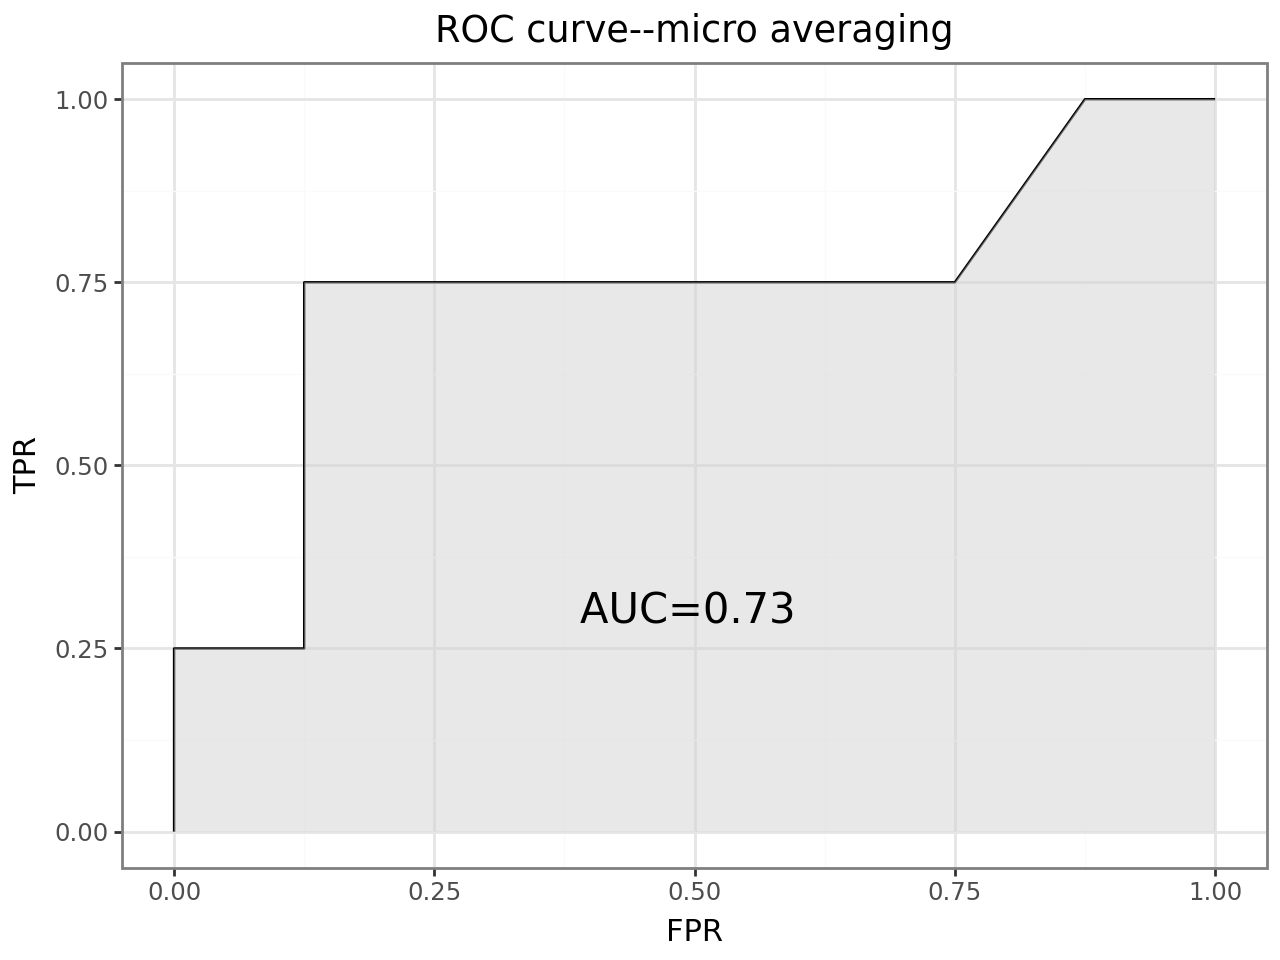

In [5]:
q=(
    ggplot(df)
    + geom_line(aes(x='FPR',y='TPR'))
    + geom_ribbon(aes(x='FPR',ymin=0, ymax='TPR'), fill='lightgray', alpha=0.5)
    + annotate("text", x=0.5, y=0.3, label=f"AUC={AUC:.2f} ", size=15)
    + ggtitle("ROC curve--micro averaging")
    + xlab("FPR")
    + ylab("TPR")
    + theme_bw()
)
q

In [13]:
def ROC_curve_macro(pred_tensor, label_tensor):
    n_class=pred_tensor.size(1)
    one_hot_labels = F.one_hot(label_tensor, num_classes=n_class)
    is_positive = one_hot_labels
    is_negative =1-one_hot_labels
    fn_diff = -is_positive
    fp_diff = is_negative
    thresh_tensor = -pred_tensor
    fn_denom= is_positive.sum(dim=0)
    fp_denom_with_na = is_negative.sum(dim=0)
    fp_denom = torch.where(fp_denom_with_na == 0, torch.tensor(-1, device=fn_denom.device), fp_denom_with_na)
    sorted_indices = torch.argsort(thresh_tensor,dim=0)
    sorted_fp_cum = torch.div(torch.gather(fp_diff, dim=0, index=sorted_indices).cumsum(0), fp_denom)
    sorted_fn_cum = -torch.div(torch.gather(fn_diff, dim=0, index=sorted_indices).flip(0).cumsum(0).flip(0) , fn_denom)
    sorted_thresh = torch.gather(thresh_tensor, dim=0, index=sorted_indices)
    #Problem starts here 
    zeros_vec=torch.zeros(1,n_class)
    FPR = torch.cat([zeros_vec, sorted_fp_cum])
    FNR = torch.cat([sorted_fn_cum, zeros_vec])
    return {
        "FPR_all_classes": FPR,
        "FNR_all_classes": FNR,
        "TPR_all_classes": 1 - FNR,
        "min(FPR,FNR)": torch.minimum(FPR, FNR),
        "min_constant": torch.cat([-torch.ones(1,n_class), sorted_thresh]),
        "max_constant": torch.cat([sorted_thresh, zeros_vec])
    }
roc=ROC_curve_macro(four_pred,four_labels)
roc_flattened={}
for name,mat in roc.items():
    mat_flattened=mat.T.flatten()
    roc_flattened[name]=mat_flattened
N,K=four_pred.size()
roc_flattened["Class"] = torch.arange(0, K).repeat_interleave(N+1)
df_macro=pd.DataFrame(roc_flattened)
df_macro["Class"]=df_macro["Class"].apply(lambda x: f"Class: {x}")
df_macro

,FPR_all_classes,FNR_all_classes,TPR_all_classes,"min(FPR,FNR)",min_constant,max_constant,Class
0,0.000000,1.0,0.0,0.000000,-1.0,-0.5,Class: 0
1,0.333333,1.0,0.0,0.333333,-0.5,-0.4,Class: 0
2,0.333333,-0.0,1.0,-0.000000,-0.4,-0.3,Class: 0
3,0.666667,-0.0,1.0,-0.000000,-0.3,-0.2,Class: 0
4,1.000000,0.0,1.0,0.000000,-0.2,0.0,Class: 0
5,0.000000,1.0,0.0,0.000000,-1.0,-0.4,Class: 1
6,0.000000,0.5,0.5,0.000000,-0.4,-0.3,Class: 1
7,0.500000,0.5,0.5,0.500000,-0.3,-0.2,Class: 1
8,0.500000,-0.0,1.0,-0.000000,-0.2,-0.1,Class: 1
9,1.000000,0.0,1.0,0.000000,-0.1,0.0,Class: 1


In [14]:
def ROC_AUC_macro_not_av(pred_tensor, label_tensor):
    roc = ROC_curve_macro(pred_tensor, label_tensor)
    FPR_diff = roc["FPR_all_classes"][1:,:]-roc["FPR_all_classes"][:-1,]
    TPR_sum = roc["TPR_all_classes"][1:,:]+roc["TPR_all_classes"][:-1,:]
    sum_FPR_TPR= torch.sum(FPR_diff*TPR_sum/2.0,dim=0)
    return sum_FPR_TPR
def ROC_AUC_macro(pred_tensor, label_tensor):
    roc = ROC_curve_macro(pred_tensor, label_tensor)
    FPR_diff = roc["FPR_all_classes"][1:,:]-roc["FPR_all_classes"][:-1,]
    TPR_sum = roc["TPR_all_classes"][1:,:]+roc["TPR_all_classes"][:-1,:]
    sum_FPR_TPR= torch.sum(FPR_diff*TPR_sum/2.0,dim=0)
    count_non_defined=(sum_FPR_TPR == 0).sum()
    if count_non_defined==pred_tensor.size(1):
        return 0
    return  sum_FPR_TPR.sum()/(pred_tensor.size(1)-count_non_defined)
AUC_macro =ROC_AUC_macro_not_av(four_pred,four_labels)
AUC_av=ROC_AUC_macro(four_pred,four_labels)
text_df = pd.DataFrame({
    'Class': ['Class: 0', 'Class: 1', 'Class: 2'],
    'x': [0.6, 0.6, 0.6],      # x-position in each plot
    'y': [0.5, 0.25, 0.5],      # y-position in each plot
    'labels' : [f"AUC = {x:.2f}" for x in AUC_macro.tolist()]
})

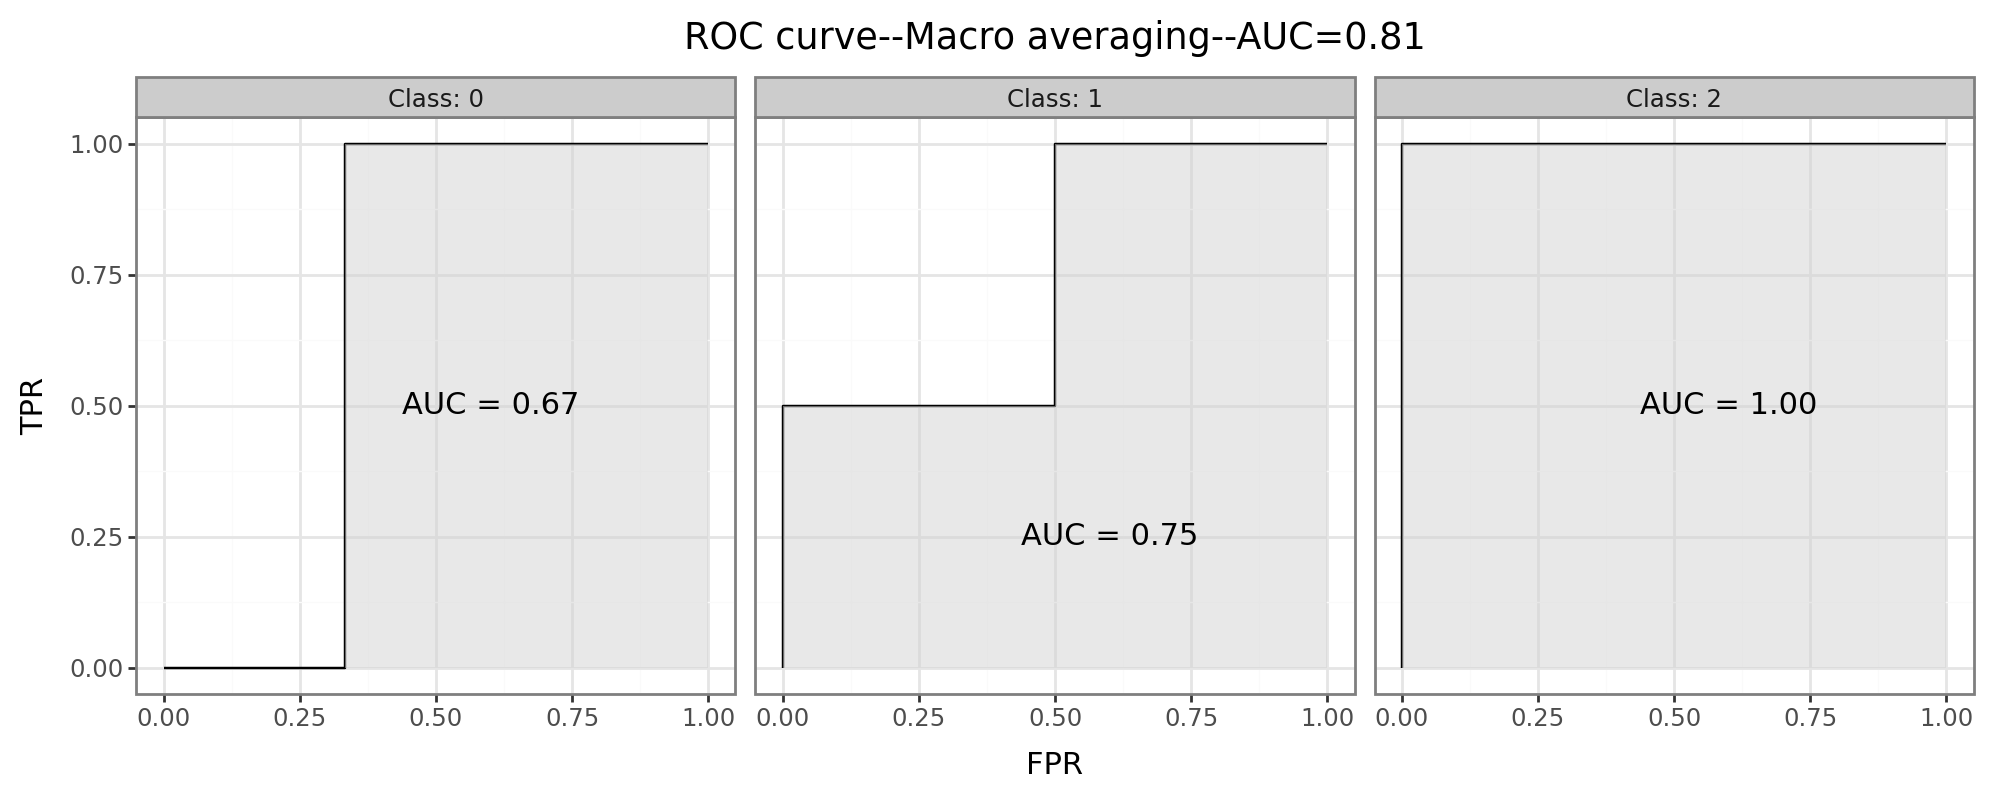

In [15]:
q=(
    ggplot(df_macro,aes(x='FPR_all_classes',y='TPR_all_classes'))
    + geom_line()
    + geom_ribbon(aes(ymin=0, ymax='TPR_all_classes'), fill='lightgray', alpha=0.5)
    + geom_text(text_df, aes(x='x', y='y', label='labels'))
    + ggtitle(f"ROC curve--Macro averaging--AUC={AUC_av:.2f}")
    + facet_grid('~Class ')
    + xlab("FPR")
    + ylab("TPR")
    + theme_bw()
    + theme(figure_size=(10, 4))

)
q

In [16]:
df_long = pd.melt(df_macro, id_vars=["min_constant","max_constant","Class"],
                  value_vars=["FPR_all_classes", "FNR_all_classes","min(FPR,FNR)"],
                  var_name="Error type", value_name="y")
df_long['is_min'] = df_long['Error type'].apply(
    lambda t: 'min(FPR,FNR)' if t == 'min(FPR,FNR)' else 'other'
)
df_area=df_macro[["min_constant","max_constant","min(FPR,FNR)","Class"]]
x_top = []
y_top = []
class_name=[]
x_bottom = []
y_bottom = []

for _, row in df_area.iterrows():
    x_top.extend([row['min_constant'], row['max_constant']])
    y_top.extend([row['min(FPR,FNR)'], row['min(FPR,FNR)']])
    class_name.extend([row['Class'],row['Class']])
    x_bottom.extend([row['max_constant'], row['min_constant']])
    y_bottom.extend([0, 0])

poly_df = pd.DataFrame({
    'x': x_top + x_bottom,
    'y': y_top + y_bottom,
    'Class': class_name+class_name

})

In [17]:
def Proposed_AUM_macro_not_averaged(pred_tensor, label_tensor):

    roc = ROC_curve_macro(pred_tensor, label_tensor)
    min_FPR_FNR = roc["min(FPR,FNR)"][1:-1,:]
    constant_diff = roc["min_constant"][1:,:].diff(dim=0)
    sum_min= torch.sum(min_FPR_FNR * constant_diff,dim=0)
    return sum_min
def Proposed_AUM(pred_tensor, label_tensor):

    roc = ROC_curve_macro(pred_tensor, label_tensor)
    min_FPR_FNR = roc["min(FPR,FNR)"][1:-1,:]
    constant_diff = roc["min_constant"][1:,:].diff(dim=0)
    sum_min= torch.sum(min_FPR_FNR * constant_diff,dim=0)
    count_non_defined=(sum_min== 0).sum()
    if count_non_defined==pred_tensor.size(1):
        return 0
    return  sum_min.sum()/(pred_tensor.size(1)-count_non_defined)
AUM_macro=Proposed_AUM_macro_not_averaged(four_pred,four_labels)
AUM_av=Proposed_AUM(four_pred,four_labels)
text_df_aum = pd.DataFrame({
    'Class': ['Class: 0', 'Class: 1', 'Class: 2'],
    'x': [-0.45, -0.25, -0.5],      # x-position in each plot
    'y': [0.15, 0.25, 0.5],      # y-position in each plot
    'labels' : [f"AUM = {x:.2f}" for x in AUM_macro.tolist()]
})

c:\Users\nou-z\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\scales\scale_size.py:46: PlotnineWarning: Using size for a discrete variable is not advised.


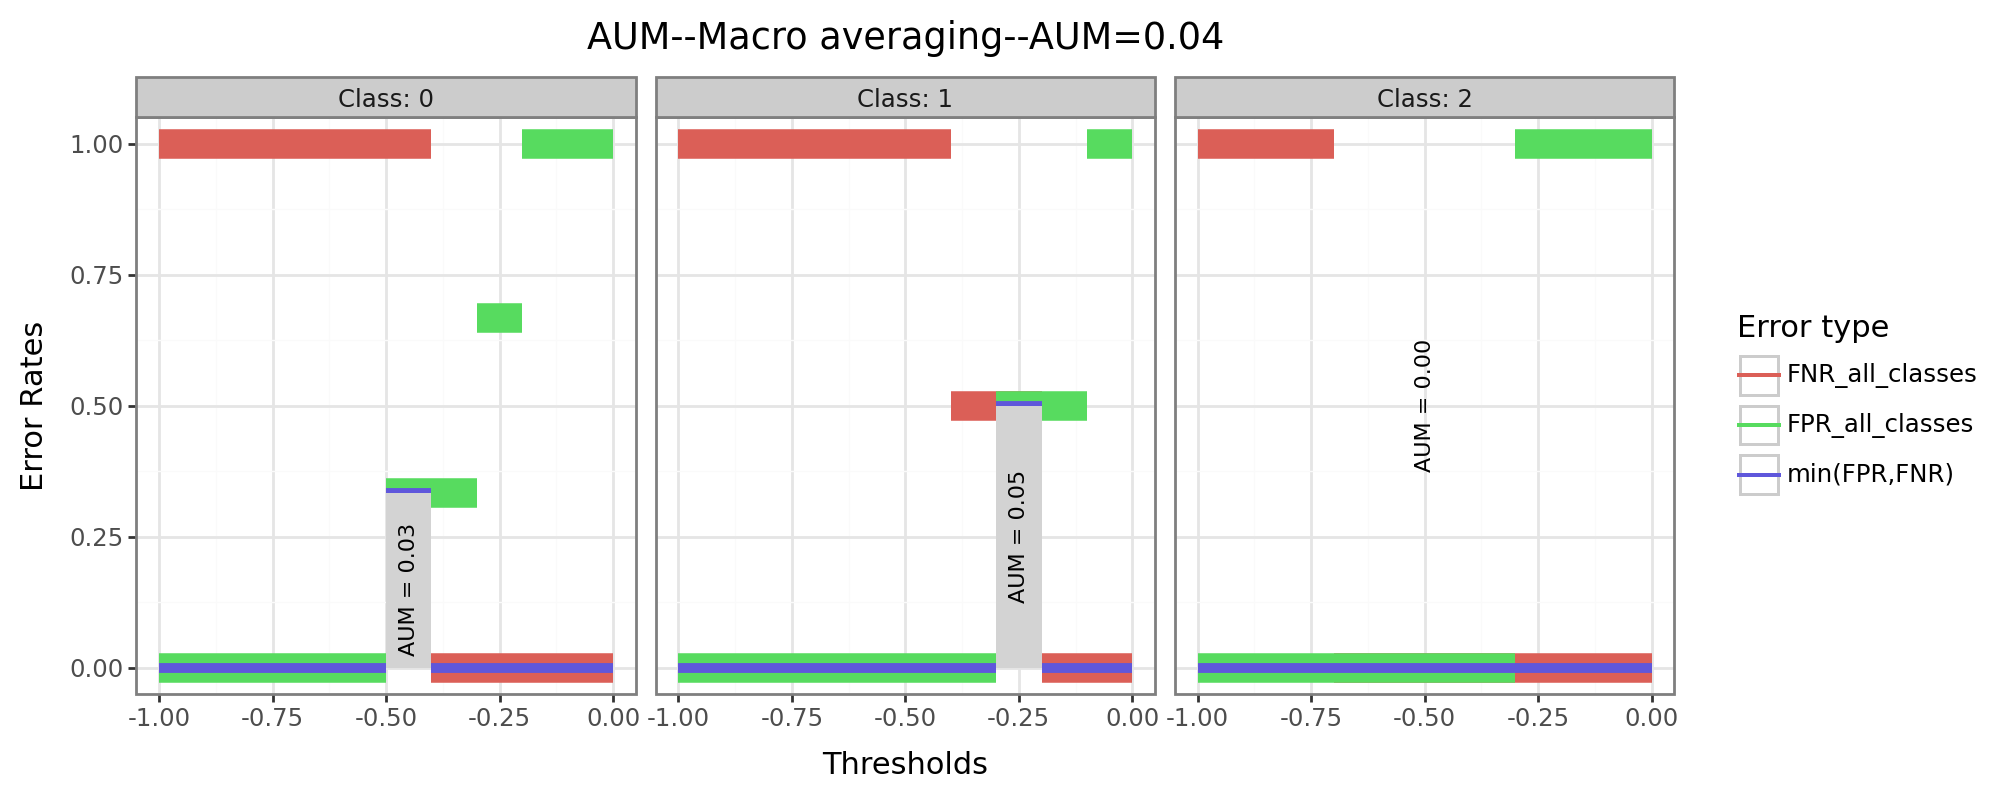

In [18]:
p = (
    ggplot()
    + geom_segment(df_long, aes(x='min_constant', y='y', xend='max_constant', yend='y', color='Error type',size='is_min'))
    + ggtitle(f"AUM--Macro averaging--AUM={AUM_av:.2f}")
    + geom_polygon(poly_df,aes(x='x', y='y'), fill='lightgray', alpha=1)
    + geom_text(text_df_aum, aes(x='x', y='y', label='labels'),angle=90, size=8)
    + xlab("Thresholds")
    + ylab("Error Rates")
    + facet_grid('~Class ')
    +theme_bw()
    + guides(size='none')
    + theme(figure_size=(10, 4))
)
p